# CNN & Huấn luyện

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import json
from PIL import Image

from data_pipeline import train_loader, test_loader, NUM_CLASSES, test_transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Thiết bị đang sử dụng để huấn luyện: {str(device)}")
print(f"Tổng số class chữ Hán nhận diện: {NUM_CLASSES}")
print(f"Số Batch tập Train: {len(train_loader)} | Tập Test: {len(test_loader)}")

Đang nạp tập Train từ HDF5...
Đang nạp tập Test từ HDF5...
Đã load mapping.json thành công với 7185 chữ Hán.
Tổng số batch trong tập Train: 12023
Tổng số batch trong tập Test: 2899
✅ Sẵn sàng đưa vào file model.ipynb
Thiết bị đang sử dụng để huấn luyện: cuda
Tổng số class chữ Hán nhận diện: 7185
Số Batch tập Train: 12023 | Tập Test: 2899


In [ ]:
torch.backends.cudnn.benchmark = True

class HanziCNN(nn.Module):
    def __init__(self, num_classes):
        super(HanziCNN, self).__init__()
        
        # 64x64 -> 32x32
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, padding=2),
            nn.BatchNorm2d(num_features=32), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # 32x32 -> 16x16
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=64), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # 16x16 -> 8x8
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=128), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # 8x8 -> 4x4
        self.block4 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=256), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Lớp GAP biến ma trận 4x4 -> vector 256 chiều
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features=256, out_features=num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = HanziCNN(num_classes=NUM_CLASSES).to(device)

✅ Khởi tạo mạng CNN 4 Block thành công!


In [ ]:
import torch.optim.lr_scheduler as lr_scheduler 

EPOCHS = 50 
learning_rate = 0.001

# 7 vòng liên tiếp mà Loss ko giảm thì sẽ Early Stopping
PATIENCE = 7 

# Nếu 2 vòng liên tiếp mà Loss ko giảm thì sẽ giảm Learning Rate
LR_PATIENCE = 2 

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',           # Mục tiêu là theo dõi Loss
    factor=0.5,           # Giảm LR đi 1 nửa
    patience=LR_PATIENCE
)

In [ ]:
print(f"BẮT ĐẦU HUẤN LUYỆN (Tối đa {EPOCHS} Epochs - Tích hợp ReduceLROnPlateau & Early Stopping)...")

# Lưu Model dựa trên Loss thấp nhất trên tập Validation
best_loss = float('inf') 
epochs_no_improve = 0 
best_acc = 0.0 

for epoch in range(EPOCHS):
    start_time = time.time()

    # =========================
    # GIAI ĐOẠN 1: TRAINING
    # =========================
    model.train()
    running_loss = 0.0
    correct_train = total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = 100 * correct_train / total_train
    train_loss = running_loss / len(train_loader)

    # =========================
    # GIAI ĐOẠN 2: TESTING (Tính thêm val_loss)
    # =========================
    model.eval()
    test_loss = 0.0 
    correct_test = total_test = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            # Tính Val Loss để đưa cho Scheduler và Early Stopping
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_acc = 100 * correct_test / total_test
    val_loss = test_loss / len(test_loader) # Tính trung bình Val Loss của vòng này

    # =========================
    # GIAI ĐOẠN 3: ĐIỀU CHỈNH LR & EARLY STOPPING
    # =========================
    
    # 1. Nạp val_loss cho thuật toán bóp phanh (Nó sẽ tự hạ LR nếu cần)
    scheduler.step(val_loss)

    # 2. Logic Early Stopping (so sánh val_loss với kỷ lục best_loss)
    if val_loss < best_loss: 
        best_loss = val_loss
        best_acc = test_acc # Cập nhật điểm Acc để in ra lúc cuối
        torch.save(model.state_dict(), 'hanzi_best_weight.pth')
        epochs_no_improve = 0 # Đã phá kỷ lục -> Reset bộ đếm vi phạm về 0
        saved_msg = "⭐ Đã lưu Model (Kỷ lục Loss mới)!"
    else:
        epochs_no_improve += 1 # Không phá kỷ lục -> Ghi nhận 1 lần vi phạm
        saved_msg = f"❌ Loss không giảm ({epochs_no_improve}/{PATIENCE})"

    # =========================
    # GIAI ĐOẠN 4: IN KẾT QUẢ VÒNG LẶP
    # =========================
    epoch_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr'] # Lấy tốc độ học hiện tại để in ra
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Thời gian: {epoch_time:.0f}s | Tốc độ học (LR): {current_lr}")
    print(f"   📉 Train Loss: {train_loss:.4f} | 🎯 Train Acc: {train_acc:.2f}%")
    print(f"   📊 Val Loss:   {val_loss:.4f} | 🏆 Val Acc:   {test_acc:.2f}% -> {saved_msg}")
    print("-" * 50)

    # 3. Kích hoạt Early Stopping
    if epochs_no_improve >= PATIENCE:
        print(f"🛑 KÍCH HOẠT EARLY STOPPING! Mô hình không thể giảm Loss thêm sau {PATIENCE} epochs.")
        print(f"Tự động ngắt ở Epoch {epoch+1} để khóa chặt trạng thái tốt nhất.")
        break

print(f"🎉 ĐÃ HUẤN LUYỆN XONG! Điểm Test cao nhất (tương ứng với Loss thấp nhất): {best_acc:.2f}%")
print("Trọng số tối ưu nhất đã được lưu vào file 'hanzi_best_weight.pth'")

BẮT ĐẦU HUẤN LUYỆN (Tối đa 50 Epochs - Tích hợp ReduceLROnPlateau & Early Stopping)...
Epoch [1/50] | Thời gian: 2129s | Tốc độ học (LR): 0.001
   📉 Train Loss: 2.9064 | 🎯 Train Acc: 46.74%
   📊 Val Loss:   0.9209 | 🏆 Val Acc:   76.53% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [2/50] | Thời gian: 2682s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.8663 | 🎯 Train Acc: 77.79%
   📊 Val Loss:   0.6235 | 🏆 Val Acc:   83.65% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [3/50] | Thời gian: 2795s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.6728 | 🎯 Train Acc: 82.46%
   📊 Val Loss:   0.4534 | 🏆 Val Acc:   88.21% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [4/50] | Thời gian: 3038s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.5852 | 🎯 Train Acc: 84.65%
   📊 Val Loss:   0.4051 | 🏆 Val Acc:   89.49% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
----------------

# Biểu đồ Acc & Loss trên tập Val

Đã vẽ xong biểu đồ.


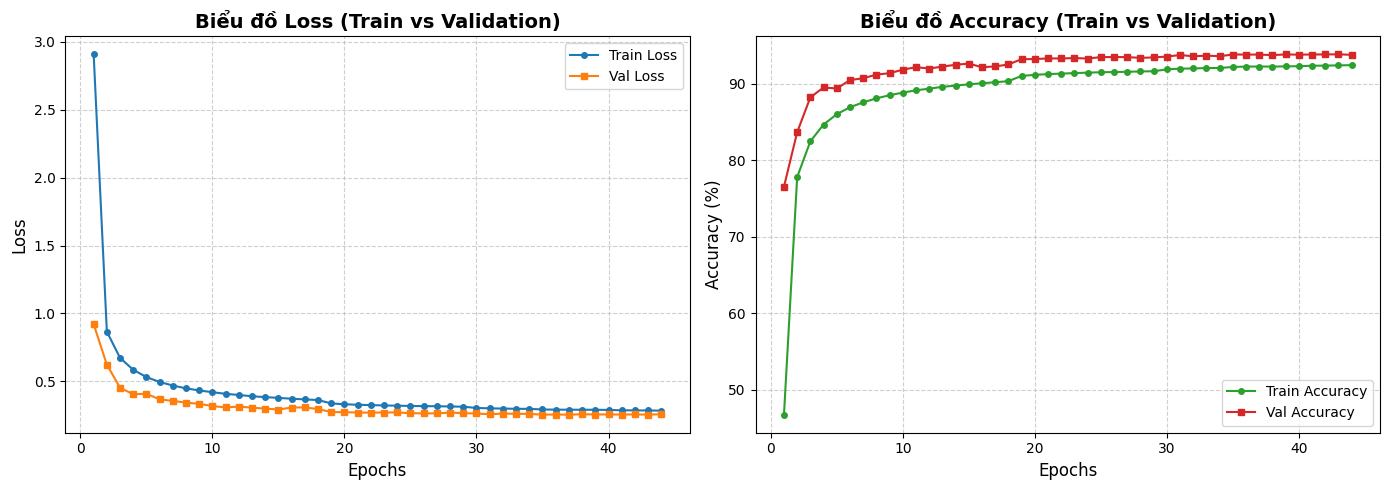

In [4]:
import re
import matplotlib.pyplot as plt

log_data = """
Epoch [1/50] | Thời gian: 2129s | Tốc độ học (LR): 0.001
   📉 Train Loss: 2.9064 | 🎯 Train Acc: 46.74%
   📊 Val Loss:   0.9209 | 🏆 Val Acc:   76.53% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [2/50] | Thời gian: 2682s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.8663 | 🎯 Train Acc: 77.79%
   📊 Val Loss:   0.6235 | 🏆 Val Acc:   83.65% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [3/50] | Thời gian: 2795s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.6728 | 🎯 Train Acc: 82.46%
   📊 Val Loss:   0.4534 | 🏆 Val Acc:   88.21% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [4/50] | Thời gian: 3038s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.5852 | 🎯 Train Acc: 84.65%
   📊 Val Loss:   0.4051 | 🏆 Val Acc:   89.49% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [5/50] | Thời gian: 2548s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.5319 | 🎯 Train Acc: 86.00%
   📊 Val Loss:   0.4094 | 🏆 Val Acc:   89.36% -> ❌ Loss không giảm (1/7)
--------------------------------------------------
Epoch [6/50] | Thời gian: 2972s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.4957 | 🎯 Train Acc: 86.91%
   📊 Val Loss:   0.3677 | 🏆 Val Acc:   90.46% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [7/50] | Thời gian: 2912s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.4699 | 🎯 Train Acc: 87.55%
   📊 Val Loss:   0.3566 | 🏆 Val Acc:   90.70% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [8/50] | Thời gian: 2242s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.4488 | 🎯 Train Acc: 88.07%
   📊 Val Loss:   0.3440 | 🏆 Val Acc:   91.17% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [9/50] | Thời gian: 3085s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.4336 | 🎯 Train Acc: 88.48%
   📊 Val Loss:   0.3349 | 🏆 Val Acc:   91.36% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [10/50] | Thời gian: 3048s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.4206 | 🎯 Train Acc: 88.82%
   📊 Val Loss:   0.3187 | 🏆 Val Acc:   91.81% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [11/50] | Thời gian: 2840s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.4087 | 🎯 Train Acc: 89.12%
   📊 Val Loss:   0.3089 | 🏆 Val Acc:   92.15% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [12/50] | Thời gian: 2870s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.4002 | 🎯 Train Acc: 89.34%
   📊 Val Loss:   0.3147 | 🏆 Val Acc:   91.97% -> ❌ Loss không giảm (1/7)
--------------------------------------------------
Epoch [13/50] | Thời gian: 2711s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.3910 | 🎯 Train Acc: 89.57%
   📊 Val Loss:   0.3069 | 🏆 Val Acc:   92.22% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [14/50] | Thời gian: 3075s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.3845 | 🎯 Train Acc: 89.74%
   📊 Val Loss:   0.3001 | 🏆 Val Acc:   92.46% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [15/50] | Thời gian: 2906s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.3790 | 🎯 Train Acc: 89.90%
   📊 Val Loss:   0.2930 | 🏆 Val Acc:   92.61% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [16/50] | Thời gian: 2913s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.3726 | 🎯 Train Acc: 90.05%
   📊 Val Loss:   0.3080 | 🏆 Val Acc:   92.14% -> ❌ Loss không giảm (1/7)
--------------------------------------------------
Epoch [17/50] | Thời gian: 3094s | Tốc độ học (LR): 0.001
   📉 Train Loss: 0.3677 | 🎯 Train Acc: 90.17%
   📊 Val Loss:   0.3087 | 🏆 Val Acc:   92.24% -> ❌ Loss không giảm (2/7)
--------------------------------------------------
Epoch [18/50] | Thời gian: 3083s | Tốc độ học (LR): 0.0005
   📉 Train Loss: 0.3630 | 🎯 Train Acc: 90.32%
   📊 Val Loss:   0.2967 | 🏆 Val Acc:   92.50% -> ❌ Loss không giảm (3/7)
--------------------------------------------------
Epoch [19/50] | Thời gian: 2895s | Tốc độ học (LR): 0.0005
   📉 Train Loss: 0.3380 | 🎯 Train Acc: 91.00%
   📊 Val Loss:   0.2744 | 🏆 Val Acc:   93.19% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [20/50] | Thời gian: 3071s | Tốc độ học (LR): 0.0005
   📉 Train Loss: 0.3320 | 🎯 Train Acc: 91.14%
   📊 Val Loss:   0.2741 | 🏆 Val Acc:   93.20% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [21/50] | Thời gian: 2810s | Tốc độ học (LR): 0.0005
   📉 Train Loss: 0.3282 | 🎯 Train Acc: 91.24%
   📊 Val Loss:   0.2708 | 🏆 Val Acc:   93.29% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [22/50] | Thời gian: 3108s | Tốc độ học (LR): 0.0005
   📉 Train Loss: 0.3257 | 🎯 Train Acc: 91.30%
   📊 Val Loss:   0.2705 | 🏆 Val Acc:   93.28% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [23/50] | Thời gian: 3163s | Tốc độ học (LR): 0.0005
   📉 Train Loss: 0.3232 | 🎯 Train Acc: 91.37%
   📊 Val Loss:   0.2713 | 🏆 Val Acc:   93.34% -> ❌ Loss không giảm (1/7)
--------------------------------------------------
Epoch [24/50] | Thời gian: 2618s | Tốc độ học (LR): 0.0005
   📉 Train Loss: 0.3214 | 🎯 Train Acc: 91.43%
   📊 Val Loss:   0.2717 | 🏆 Val Acc:   93.27% -> ❌ Loss không giảm (2/7)
--------------------------------------------------
Epoch [25/50] | Thời gian: 2631s | Tốc độ học (LR): 0.0005
   📉 Train Loss: 0.3195 | 🎯 Train Acc: 91.48%
   📊 Val Loss:   0.2663 | 🏆 Val Acc:   93.46% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [26/50] | Thời gian: 3138s | Tốc độ học (LR): 0.0005
   📉 Train Loss: 0.3182 | 🎯 Train Acc: 91.51%
   📊 Val Loss:   0.2648 | 🏆 Val Acc:   93.47% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [27/50] | Thời gian: 3148s | Tốc độ học (LR): 0.0005
   📉 Train Loss: 0.3173 | 🎯 Train Acc: 91.54%
   📊 Val Loss:   0.2650 | 🏆 Val Acc:   93.46% -> ❌ Loss không giảm (1/7)
--------------------------------------------------
Epoch [28/50] | Thời gian: 2964s | Tốc độ học (LR): 0.0005
   📉 Train Loss: 0.3156 | 🎯 Train Acc: 91.59%
   📊 Val Loss:   0.2706 | 🏆 Val Acc:   93.36% -> ❌ Loss không giảm (2/7)
--------------------------------------------------
Epoch [29/50] | Thời gian: 3187s | Tốc độ học (LR): 0.00025
   📉 Train Loss: 0.3140 | 🎯 Train Acc: 91.61%
   📊 Val Loss:   0.2662 | 🏆 Val Acc:   93.42% -> ❌ Loss không giảm (3/7)
--------------------------------------------------
Epoch [30/50] | Thời gian: 3024s | Tốc độ học (LR): 0.00025
   📉 Train Loss: 0.3047 | 🎯 Train Acc: 91.86%
   📊 Val Loss:   0.2640 | 🏆 Val Acc:   93.53% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [31/50] | Thời gian: 2637s | Tốc độ học (LR): 0.00025
   📉 Train Loss: 0.3020 | 🎯 Train Acc: 91.95%
   📊 Val Loss:   0.2582 | 🏆 Val Acc:   93.73% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [32/50] | Thời gian: 3198s | Tốc độ học (LR): 0.00025
   📉 Train Loss: 0.3002 | 🎯 Train Acc: 91.98%
   📊 Val Loss:   0.2632 | 🏆 Val Acc:   93.57% -> ❌ Loss không giảm (1/7)
--------------------------------------------------
Epoch [33/50] | Thời gian: 2963s | Tốc độ học (LR): 0.00025
   📉 Train Loss: 0.2986 | 🎯 Train Acc: 92.03%
   📊 Val Loss:   0.2616 | 🏆 Val Acc:   93.65% -> ❌ Loss không giảm (2/7)
--------------------------------------------------
Epoch [34/50] | Thời gian: 2870s | Tốc độ học (LR): 0.000125
   📉 Train Loss: 0.2980 | 🎯 Train Acc: 92.04%
   📊 Val Loss:   0.2608 | 🏆 Val Acc:   93.58% -> ❌ Loss không giảm (3/7)
--------------------------------------------------
Epoch [35/50] | Thời gian: 3135s | Tốc độ học (LR): 0.000125
   📉 Train Loss: 0.2936 | 🎯 Train Acc: 92.17%
   📊 Val Loss:   0.2556 | 🏆 Val Acc:   93.80% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [36/50] | Thời gian: 3192s | Tốc độ học (LR): 0.000125
   📉 Train Loss: 0.2922 | 🎯 Train Acc: 92.22%
   📊 Val Loss:   0.2565 | 🏆 Val Acc:   93.79% -> ❌ Loss không giảm (1/7)
--------------------------------------------------
Epoch [37/50] | Thời gian: 3190s | Tốc độ học (LR): 0.000125
   📉 Train Loss: 0.2920 | 🎯 Train Acc: 92.23%
   📊 Val Loss:   0.2551 | 🏆 Val Acc:   93.79% -> ⭐ Đã lưu Model (Kỷ lục Loss mới)!
--------------------------------------------------
Epoch [38/50] | Thời gian: 2477s | Tốc độ học (LR): 0.000125
   📉 Train Loss: 0.2916 | 🎯 Train Acc: 92.22%
   📊 Val Loss:   0.2589 | 🏆 Val Acc:   93.72% -> ❌ Loss không giảm (1/7)
--------------------------------------------------
Epoch [39/50] | Thời gian: 3195s | Tốc độ học (LR): 0.000125
   📉 Train Loss: 0.2914 | 🎯 Train Acc: 92.25%
   📊 Val Loss:   0.2564 | 🏆 Val Acc:   93.81% -> ❌ Loss không giảm (2/7)
--------------------------------------------------
Epoch [40/50] | Thời gian: 3177s | Tốc độ học (LR): 6.25e-05
   📉 Train Loss: 0.2901 | 🎯 Train Acc: 92.27%
   📊 Val Loss:   0.2571 | 🏆 Val Acc:   93.78% -> ❌ Loss không giảm (3/7)
--------------------------------------------------
Epoch [41/50] | Thời gian: 2968s | Tốc độ học (LR): 6.25e-05
   📉 Train Loss: 0.2877 | 🎯 Train Acc: 92.33%
   📊 Val Loss:   0.2565 | 🏆 Val Acc:   93.80% -> ❌ Loss không giảm (4/7)
--------------------------------------------------
Epoch [42/50] | Thời gian: 2935s | Tốc độ học (LR): 6.25e-05
   📉 Train Loss: 0.2869 | 🎯 Train Acc: 92.35%
   📊 Val Loss:   0.2570 | 🏆 Val Acc:   93.81% -> ❌ Loss không giảm (5/7)
--------------------------------------------------
Epoch [43/50] | Thời gian: 3170s | Tốc độ học (LR): 3.125e-05
   📉 Train Loss: 0.2863 | 🎯 Train Acc: 92.38%
   📊 Val Loss:   0.2560 | 🏆 Val Acc:   93.82% -> ❌ Loss không giảm (6/7)
--------------------------------------------------
Epoch [44/50] | Thời gian: 2955s | Tốc độ học (LR): 3.125e-05
   📉 Train Loss: 0.2848 | 🎯 Train Acc: 92.41%
   📊 Val Loss:   0.2583 | 🏆 Val Acc:   93.76% -> ❌ Loss không giảm (7/7)
"""

train_loss, train_acc, val_loss, val_acc = [], [], [], []
epochs = list(range(1, 45))

for line in log_data.split('\n'):
    if "Train Loss" in line:
        match = re.search(r'Train Loss: ([\d.]+).*Train Acc: ([\d.]+)', line)
        if match:
            train_loss.append(float(match.group(1)))
            train_acc.append(float(match.group(2)))
    elif "Val Loss" in line:
        match = re.search(r'Val Loss:\s+([\d.]+).*Val Acc:\s+([\d.]+)', line)
        if match:
            val_loss.append(float(match.group(1)))
            val_acc.append(float(match.group(2)))

plt.figure(figsize=(14, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss', color='#1f77b4', marker='o', markersize=4)
plt.plot(epochs, val_loss, label='Val Loss', color='#ff7f0e', marker='s', markersize=4)
plt.title('Biểu đồ Loss (Train vs Validation)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, label='Train Accuracy', color='#2ca02c', marker='o', markersize=4)
plt.plot(epochs, val_acc, label='Val Accuracy', color='#d62728', marker='s', markersize=4)
plt.title('Biểu đồ Accuracy (Train vs Validation)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300)
print("Đã vẽ xong biểu đồ.")

# Số lượng tham số

In [ ]:
from torchinfo import summary

model.load_state_dict(torch.load('Tao_hanzi_best_weight.pth', map_location=device))

summary(model, input_size=(1, 1, 64, 64), 
        col_names=["input_size", "output_size", "num_params"], 
        depth=3)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
HanziCNN                                 [1, 1, 64, 64]            [1, 7185]                 --
├─Sequential: 1-1                        [1, 1, 64, 64]            [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 1, 64, 64]            [1, 32, 64, 64]           832
│    └─BatchNorm2d: 2-2                  [1, 32, 64, 64]           [1, 32, 64, 64]           64
│    └─ReLU: 2-3                         [1, 32, 64, 64]           [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-4                    [1, 32, 64, 64]           [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 32, 32]           [1, 64, 16, 16]           --
│    └─Conv2d: 2-5                       [1, 32, 32, 32]           [1, 64, 32, 32]           18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 32, 32]           [1, 64, 32, 32]           128
│    └─ReLU: 2-7             

# Classification report

In [ ]:
from sklearn.metrics import classification_report
import numpy as np
from data_pipeline import test_loader 

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader: 
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

report = classification_report(y_true, y_pred, digits=4, output_dict=True)
print(f"Accuracy:  {report['accuracy']:.4f}")
print(f"Macro Avg (Precision): {report['macro avg']['precision']:.4f}")
print(f"Macro Avg (Recall):    {report['macro avg']['recall']:.4f}")
print(f"Macro Avg (F1-Score):  {report['macro avg']['f1-score']:.4f}")

Accuracy:  0.9379
Macro Avg (Precision): 0.9342
Macro Avg (Recall):    0.9461
Macro Avg (F1-Score):  0.9383


# Ma trận nhầm lẫn cho vài lớp ký tự gần giống nhau về nét

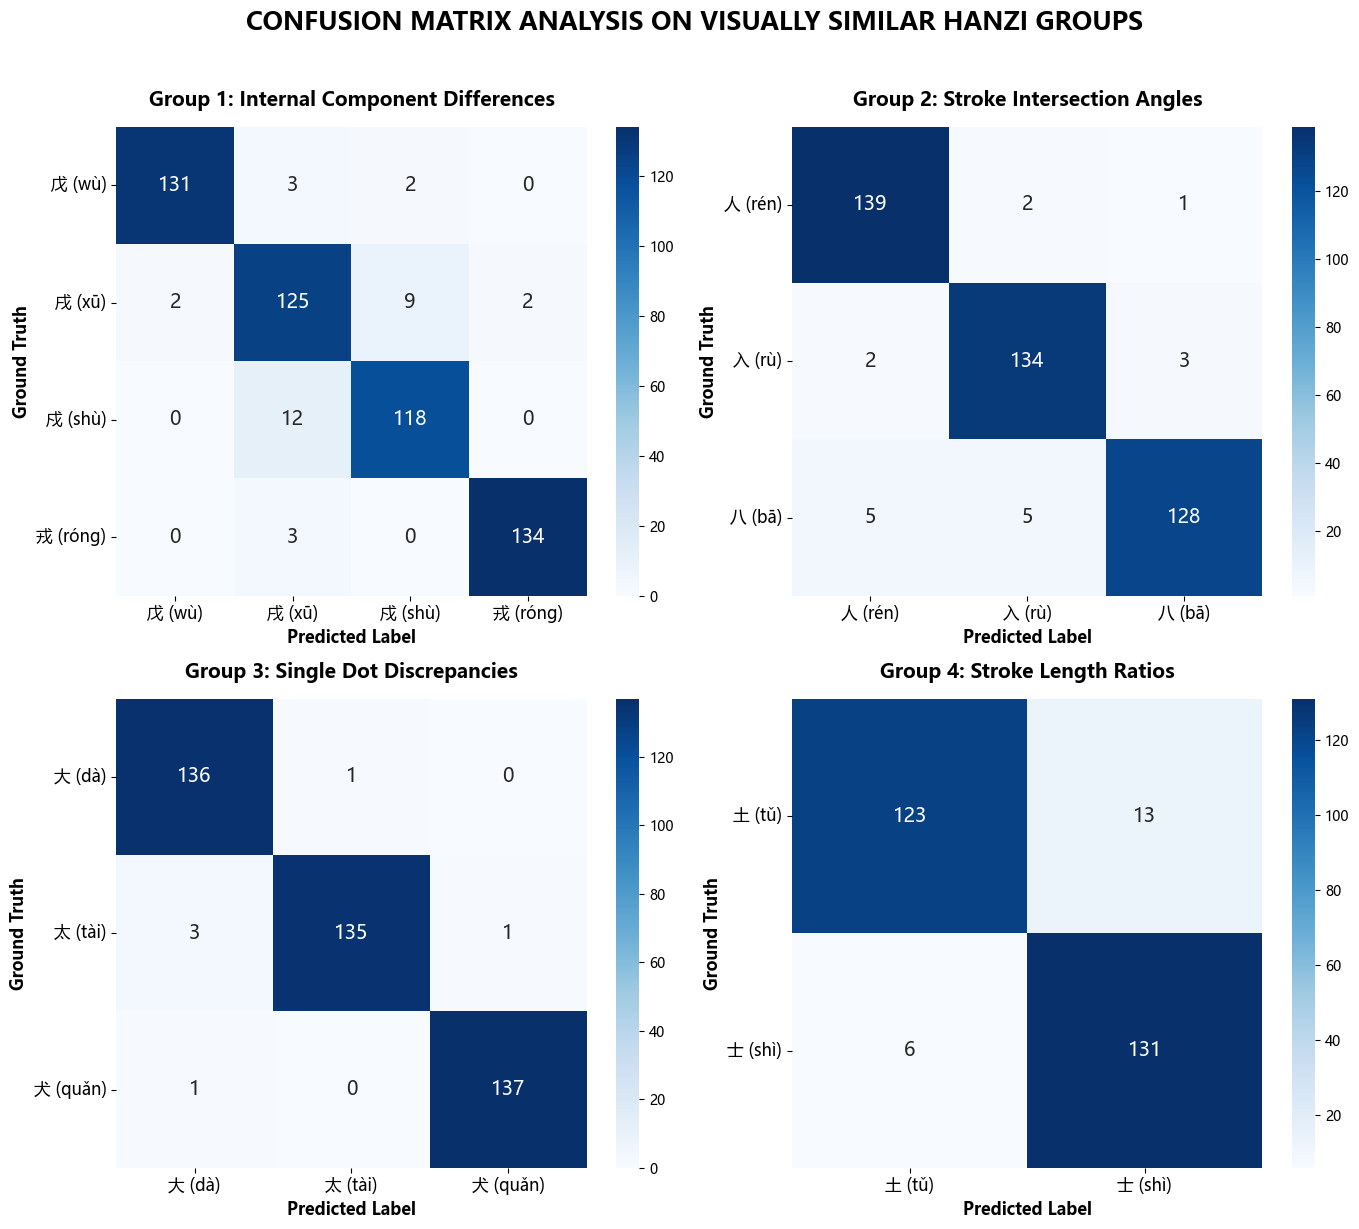

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib

# =========================================================
# RESET VÀ THIẾT LẬP FONT TOÀN CỤC 
# =========================================================
plt.rcdefaults()

# Cấu hình font 
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimSun', 'Arial Unicode MS', 'Arial']
matplotlib.rcParams['axes.unicode_minus'] = False

confusing_groups = {
    "Group 1: Internal Component Differences": {
        "indices": [2014, 2016, 2017, 2018], 
        "labels": ['戊 (wù)', '戌 (xū)', '戍 (shù)', '戎 (róng)']
    },
    "Group 2: Stroke Intersection Angles": {
        "indices": [109, 369, 371],      
        "labels": ['人 (rén)', '入 (rù)', '八 (bā)']
    },
    "Group 3: Single Dot Discrepancies": {
        "indices": [1204, 1206, 3523],     
        "labels": ['大 (dà)', '太 (tài)', '犬 (quǎn)']
    },
    "Group 4: Stroke Length Ratios": {
        "indices": [1026, 1183],          
        "labels": ['土 (tǔ)', '士 (shì)']
    }
}

# =========================================================
# VẼ GỘP 4 MA TRẬN (SUBPLOTS 2x2)
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (group_name, data) in enumerate(confusing_groups.items()):
    idx = data["indices"]
    lbls = data["labels"]
    
    # Tính toán ma trận nhầm lẫn
    cm = confusion_matrix(y_true, y_pred, labels=idx)
    
    # Vẽ Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=lbls, yticklabels=lbls, ax=axes[i],
                annot_kws={"size": 14}) 
    
    # Thiết lập tiêu đề nhóm và nhãn trục hoàn toàn bằng Tiếng Anh
    axes[i].set_title(group_name, fontsize=14, fontweight='bold', pad=15)
    axes[i].set_ylabel('Ground Truth', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', labelsize=12)
    axes[i].tick_params(axis='y', labelsize=12, rotation=0)

# Tiêu đề lớn tổng thể bằng Tiếng Anh
plt.suptitle("CONFUSION MATRIX ANALYSIS ON VISUALLY SIMILAR HANZI GROUPS", 
             fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()